In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.signal import butter, filtfilt, find_peaks, hilbert
import warnings
import re

In [2]:
# ====== PARAMETRES ======
dossier = "Coda_data"

fichiers_S01 = [
    "Gr4_S04_S1_20250011_013.txt",
    "Gr4_S04_S1_20250011_014.txt",
    "Gr4_S04_S1_20250011_015.txt",
    "Gr4_S04_S2_20250011_016.txt",
    "Gr4_S04_S2_20250011_017.txt",
    "Gr4_S04_S2_20250011_018.txt",
    "Gr4_S04_S3_20250011_019.txt",
    "Gr4_S04_S3_20250011_020.txt",
    "Gr4_S04_S3_20250011_021.txt",
    "Gr4_S04_S4_20250011_022.txt",
    "Gr4_S04_S4_20250011_023.txt",
    "Gr4_S04_S4_20250011_024.txt",
]

# ====== FILTRE PASSE-BAS ======
fs = 200
fc = 5
b, a = butter(4, fc/(fs/2), btype='low')
h = 1/fs  # pas de temps = 0.005 s

# ====== DATAFRAME FINAL ======
resultats = []

# ====== DATAFRAME POUR ANGLE ======
resultats_angle = []

for f in fichiers_S01:
    chemin = os.path.join(dossier, f)

    df = pd.read_csv(chemin, sep="\t", header=2)
    df.columns = df.columns.str.strip()
    df = df.replace("NaN", np.nan)

    colonnes_a_supprimer = [c for c in df.columns if ".V" in c or c.strip() == ""]
    df = df.drop(columns=colonnes_a_supprimer, errors="ignore")

    time_col = "Time" if "Time" in df.columns else "Time (s)"

    pattern = r"Marker (1[7-9]|20)\.[XYZ]"
    
    colonnes_markers = [c for c in df.columns if re.search(pattern, c)]
    df = df[[time_col] + colonnes_markers]
    df = df.apply(pd.to_numeric, errors="coerce")

    # ====== CENTRE RECTANGLE ======
    cx = ((df["Marker 17.X"] + df["Marker 18.X"])/2 +
          (df["Marker 19.X"] + df["Marker 20.X"])/2)/2

    cy = ((df["Marker 17.Y"] + df["Marker 18.Y"])/2 +
          (df["Marker 19.Y"] + df["Marker 20.Y"])/2)/2

    cz = ((df["Marker 17.Z"] + df["Marker 18.Z"])/2 +
          (df["Marker 19.Z"] + df["Marker 20.Z"])/2)/2

    # ====== MILIEU MARKERS 5-6 ======
    top_x = (df["Marker 17.X"] + df["Marker 18.X"]) / 2
    top_z = (df["Marker 17.Y"] + df["Marker 18.Y"]) / 2

    # ====== INTERPOLATION NaN ======
    for signal in [cx, cy, cz, top_x, top_z]:
        nan_idx = np.isnan(signal)
        if np.any(nan_idx):
            signal[nan_idx] = np.interp(
                np.flatnonzero(nan_idx),
                np.flatnonzero(~nan_idx),
                signal[~nan_idx]
            )

    # ====== FILTRAGE ======
    cx = filtfilt(b, a, cx)
    cy = filtfilt(b, a, cy)
    cz = filtfilt(b, a, cz)

    top_x = filtfilt(b, a, top_x)
    top_z = filtfilt(b, a, top_z)

    # ====== NOM PROPRE ======
    m = re.search(r"Gr4_(S\d+)_(S\d+)_\d+_(\d+)\.txt$", f)
    if m:
        s_part = m.group(1)
        l_part = m.group(2)
        num = str(int(m.group(3)))
        col_base = f"{s_part}_{l_part}_{num}"
    else:
        col_base = f.replace(".txt","")

    # ====== DATAFRAME POSITION (comme avant) ======
    df_res = pd.DataFrame({
        "Time": df[time_col],
        f"{col_base}_X": cx,
        f"{col_base}_Y": cy,
        f"{col_base}_Z": cz
    })

    resultats.append(df_res)

    # ====== DATAFRAME POUR ANGLE ======
    df_angle = pd.DataFrame({
        "Time": df[time_col],
        f"{col_base}_center_X": cx,
        f"{col_base}_center_Y": cy,
        f"{col_base}_top_X": top_x,
        f"{col_base}_top_Z": top_z
    })

    resultats_angle.append(df_angle)


# ====== FUSION DATAFRAME POSITION ======
df_final = resultats[0]
for df in resultats[1:]:
    df_final = df_final.merge(df, on="Time")

# ====== FUSION DATAFRAME ANGLE ======
df_angle_base = resultats_angle[0]
for df in resultats_angle[1:]:
    df_angle_base = df_angle_base.merge(df, on="Time")

# ====== AFFICHAGE ======
print("✅ Fusion terminée")

print("\nColonnes df_final :")
print(df_final.columns.tolist())

print("\nColonnes df_angle_base :")
print(df_angle_base.columns.tolist())

✅ Fusion terminée

Colonnes df_final :
['Time', 'S04_S1_13_X', 'S04_S1_13_Y', 'S04_S1_13_Z', 'S04_S1_14_X', 'S04_S1_14_Y', 'S04_S1_14_Z', 'S04_S1_15_X', 'S04_S1_15_Y', 'S04_S1_15_Z', 'S04_S2_16_X', 'S04_S2_16_Y', 'S04_S2_16_Z', 'S04_S2_17_X', 'S04_S2_17_Y', 'S04_S2_17_Z', 'S04_S2_18_X', 'S04_S2_18_Y', 'S04_S2_18_Z', 'S04_S3_19_X', 'S04_S3_19_Y', 'S04_S3_19_Z', 'S04_S3_20_X', 'S04_S3_20_Y', 'S04_S3_20_Z', 'S04_S3_21_X', 'S04_S3_21_Y', 'S04_S3_21_Z', 'S04_S4_22_X', 'S04_S4_22_Y', 'S04_S4_22_Z', 'S04_S4_23_X', 'S04_S4_23_Y', 'S04_S4_23_Z', 'S04_S4_24_X', 'S04_S4_24_Y', 'S04_S4_24_Z']

Colonnes df_angle_base :
['Time', 'S04_S1_13_center_X', 'S04_S1_13_center_Y', 'S04_S1_13_top_X', 'S04_S1_13_top_Z', 'S04_S1_14_center_X', 'S04_S1_14_center_Y', 'S04_S1_14_top_X', 'S04_S1_14_top_Z', 'S04_S1_15_center_X', 'S04_S1_15_center_Y', 'S04_S1_15_top_X', 'S04_S1_15_top_Z', 'S04_S2_16_center_X', 'S04_S2_16_center_Y', 'S04_S2_16_top_X', 'S04_S2_16_top_Z', 'S04_S2_17_center_X', 'S04_S2_17_center_Y', 'S04_

In [3]:
# ===== TEMPS A OBSERVER ========
t_min = 7
t_max = 40

# ===== PARAMETRES ==========
distance_pts = 200
prominence_pts = 5

time_col = "Time"
cols = [c for c in df_final.columns if c != time_col]

# ====== SELECTION INTERVALLE TEMPS ======
mask = (df_final[time_col] >= t_min) & (df_final[time_col] <= t_max)
time_segment = df_final[time_col][mask]

# ====== STOCKAGE ======
all_min_times = {}
all_max_times = {}

for col in cols:

    signal = df_final[col][mask].values
    time_vals = time_segment.values

    # ====== DETECTION MINIMA ======
    peaks_min, _ = find_peaks(
        -signal,
        distance=distance_pts,
        prominence=prominence_pts
    )

    minima_times = list(time_vals[peaks_min])

    # enlever premier et dernier
    if len(minima_times) > 2:
        minima_times = minima_times[1:-1]

    all_min_times[col] = minima_times


    # ====== DETECTION MAXIMA ======
    peaks_max, _ = find_peaks(
        signal,
        distance=distance_pts,
        prominence=prominence_pts
    )

    maxima_times = list(time_vals[peaks_max])

    # enlever premier et dernier
    if len(maxima_times) > 2:
        maxima_times = maxima_times[1:-1]

    all_max_times[col] = maxima_times


    # ====== PRINT INFO ======
    print(f"\n📊 {col}")
    print(f"Minima détectés (après suppression bords) : {len(minima_times)}")
    print(f"Maxima détectés (après suppression bords) : {len(maxima_times)}")


# ====== DATAFRAME MINIMA ======
max_len_min = max(len(v) for v in all_min_times.values())

minima_times_df = pd.DataFrame({
    col: pd.Series(v + [np.nan]*(max_len_min - len(v)))
    for col, v in all_min_times.items()
})


# ====== DATAFRAME MAXIMA ======
max_len_max = max(len(v) for v in all_max_times.values())

maxima_times_df = pd.DataFrame({
    col: pd.Series(v + [np.nan]*(max_len_max - len(v)))
    for col, v in all_max_times.items()
})


print(f"\n✅ DataFrame des minima : {minima_times_df.shape[0]} x {minima_times_df.shape[1]}")
print(f"✅ DataFrame des maxima : {maxima_times_df.shape[0]} x {maxima_times_df.shape[1]}")


📊 S04_S1_13_X
Minima détectés (après suppression bords) : 13
Maxima détectés (après suppression bords) : 14

📊 S04_S1_13_Y
Minima détectés (après suppression bords) : 14
Maxima détectés (après suppression bords) : 15

📊 S04_S1_13_Z
Minima détectés (après suppression bords) : 14
Maxima détectés (après suppression bords) : 14

📊 S04_S1_14_X
Minima détectés (après suppression bords) : 14
Maxima détectés (après suppression bords) : 14

📊 S04_S1_14_Y
Minima détectés (après suppression bords) : 14
Maxima détectés (après suppression bords) : 14

📊 S04_S1_14_Z
Minima détectés (après suppression bords) : 14
Maxima détectés (après suppression bords) : 14

📊 S04_S1_15_X
Minima détectés (après suppression bords) : 17
Maxima détectés (après suppression bords) : 15

📊 S04_S1_15_Y
Minima détectés (après suppression bords) : 16
Maxima détectés (après suppression bords) : 14

📊 S04_S1_15_Z
Minima détectés (après suppression bords) : 14
Maxima détectés (après suppression bords) : 14

📊 S04_S2_16_X
Mini

In [4]:
# =========================================================
# 🔷 ANALYSE DES PLANS + EXTRACTION MAX/MIN EN 3D
# =========================================================

from sklearn.decomposition import PCA

# ====== STOCKAGE RESULTATS ======
plans_info = []
extrema_points = []

# ====== IDENTIFICATION DES BLOCS ======
pattern_cols = re.compile(r"^(S\d+)_(S[1-4])_(\d+)_(X|Y|Z)$")

grouped = {}

for col in df_final.columns:
    if col == "Time":
        continue
    m = pattern_cols.match(col)
    if m:
        key = (m.group(1), m.group(2), m.group(3))  # (S01, S1, 1)
        grouped.setdefault(key, []).append(col)

# =========================================================
# 🔷 1 & 2) PLAN DE REGRESSION (PCA)
# =========================================================

print("\n================ PLAN DE REGRESSION =================")

for (s, cond, bloc), cols_xyz in grouped.items():

    # récupérer X Y Z
    try:
        X = df_final[f"{s}_{cond}_{bloc}_X"].values
        Y = df_final[f"{s}_{cond}_{bloc}_Y"].values
        Z = df_final[f"{s}_{cond}_{bloc}_Z"].values
    except:
        continue

    data = np.vstack((X, Y, Z)).T

    # PCA → plan de meilleur ajustement
    pca = PCA(n_components=3)
    pca.fit(data)

    normal_vector = pca.components_[-1]  # vecteur normal au plan
    var_explained = pca.explained_variance_ratio_

    # plan = 2 premières composantes
    plane_axes = pca.components_[:2]

    # stockage
    plans_info.append({
        "Sujet": s,
        "Condition": cond,
        "Bloc": bloc,
        "Normal_X": normal_vector[0],
        "Normal_Y": normal_vector[1],
        "Normal_Z": normal_vector[2],
        "Axis1_X": plane_axes[0][0],
        "Axis1_Y": plane_axes[0][1],
        "Axis1_Z": plane_axes[0][2],
        "Axis2_X": plane_axes[1][0],
        "Axis2_Y": plane_axes[1][1],
        "Axis2_Z": plane_axes[1][2],
        "Variance_explained": var_explained[:2].sum()
    })

    # ===== PRINT DEMANDÉ =====
    print(f"\n📦 {s} | {cond} | Bloc {bloc}")
    print(f"➡️ Plan (axes principaux) :")
    print(f"   Axe 1 : {plane_axes[0]}")
    print(f"   Axe 2 : {plane_axes[1]}")
    print(f"➡️ Normal au plan : {normal_vector}")
    print(f"➡️ Variance expliquée (plan) : {var_explained[:2].sum():.3f}")

# DataFrame plan
df_plans = pd.DataFrame(plans_info)


# =========================================================
# 🔷 3) EXTRACTION DES MAX/MIN AVEC POSITION 3D
# =========================================================

print("\n================ EXTRACTION EXTREMA 3D =================")

for col in minima_times_df.columns:

    if "_Z" not in col:
        continue  # axe principal = Z

    base = col.replace("_Z", "")

    col_x = base + "_X"
    col_y = base + "_Y"

    if col_x not in df_final.columns:
        continue

    m = re.match( r"^(S\d+)_(S[1-4])_(\d+)", base)
    
    if not m:
        continue

    s, cond, bloc = m.groups()

    # ===================== MIN =====================
    times_min = minima_times_df[col].dropna().values

    for i, t in enumerate(times_min):

        idx = np.argmin(np.abs(df_final["Time"] - t))

        extrema_points.append({
            "Sujet": s,
            "Condition": cond,
            "Bloc": bloc,
            "Type": "MIN",
            "Index_extrema": i + 1,
            "Time": t,
            "X": df_final.iloc[idx][col_x],
            "Y": df_final.iloc[idx][col_y],
            "Z": df_final.iloc[idx][col]
        })

    # ===================== MAX =====================
    times_max = maxima_times_df[col].dropna().values

    for i, t in enumerate(times_max):

        idx = np.argmin(np.abs(df_final["Time"] - t))

        extrema_points.append({
            "Sujet": s,
            "Condition": cond,
            "Bloc": bloc,
            "Type": "MAX",
            "Index_extrema": i + 1,
            "Time": t,
            "X": df_final.iloc[idx][col_x],
            "Y": df_final.iloc[idx][col_y],
            "Z": df_final.iloc[idx][col]
        })

# ====== DATAFRAME FINAL EXTREMA ======
df_extrema = pd.DataFrame(extrema_points)

# tri demandé
df_extrema = df_extrema.sort_values(
    by=["Condition", "Bloc", "Type", "Index_extrema"]
).reset_index(drop=True)

print("\n✅ DataFrame extrema créé :", df_extrema.shape)

# aperçu
df_extrema.head()


================ PLAN DE REGRESSION =================

📦 S04 | S1 | Bloc 13
➡️ Plan (axes principaux) :
   Axe 1 : [-0.04074524  0.04176918  0.99829613]
   Axe 2 : [-0.03777203  0.99834726 -0.04331298]
➡️ Normal au plan : [0.99845536 0.03947247 0.03910019]
➡️ Variance expliquée (plan) : 0.987

📦 S04 | S1 | Bloc 14
➡️ Plan (axes principaux) :
   Axe 1 : [-0.05243532  0.13026149  0.99009216]
   Axe 2 : [ 0.00521674  0.99147828 -0.13016758]
➡️ Normal au plan : [0.9986107  0.00166033 0.05266802]
➡️ Variance expliquée (plan) : 0.985

📦 S04 | S1 | Bloc 15
➡️ Plan (axes principaux) :
   Axe 1 : [-0.03232186  0.21282238  0.97655616]
   Axe 2 : [ 0.05378162  0.97602144 -0.21092579]
➡️ Normal au plan : [ 0.99802948 -0.04570326  0.04299276]
➡️ Variance expliquée (plan) : 0.989

📦 S04 | S2 | Bloc 16
➡️ Plan (axes principaux) :
   Axe 1 : [-0.05486647  0.16093147  0.98543936]
   Axe 2 : [ 0.26241548  0.95455685 -0.14127752]
➡️ Normal au plan : [ 0.96339389 -0.25084314  0.09460408]
➡️ Variance expl

,Sujet,Condition,Bloc,Type,Index_extrema,Time,X,Y,Z
0,S04,S1,13,MAX,1,11.193,338.120701,-815.580783,407.268247
1,S04,S1,13,MAX,2,13.238,333.054770,-807.687404,434.454391
2,S04,S1,13,MAX,3,15.198,345.645617,-799.020483,412.138878
3,S04,S1,13,MAX,4,17.153,332.383673,-818.257794,393.962577
4,S04,S1,13,MAX,5,19.113,331.020525,-808.498747,391.506949


✅ DataFrame distances créé : (324, 6)
✅ DataFrame distances avec modulo variable créé : (324, 7)


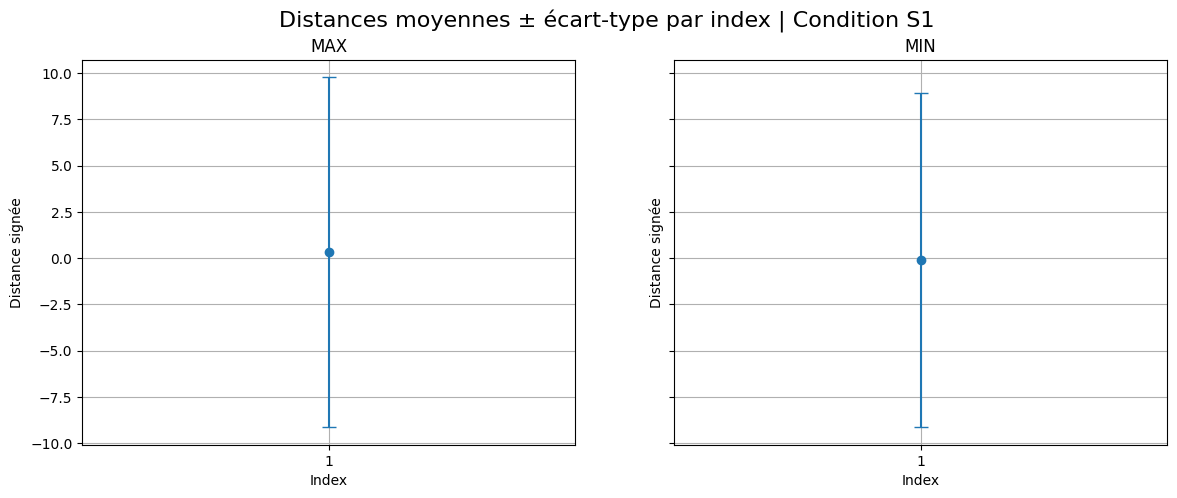

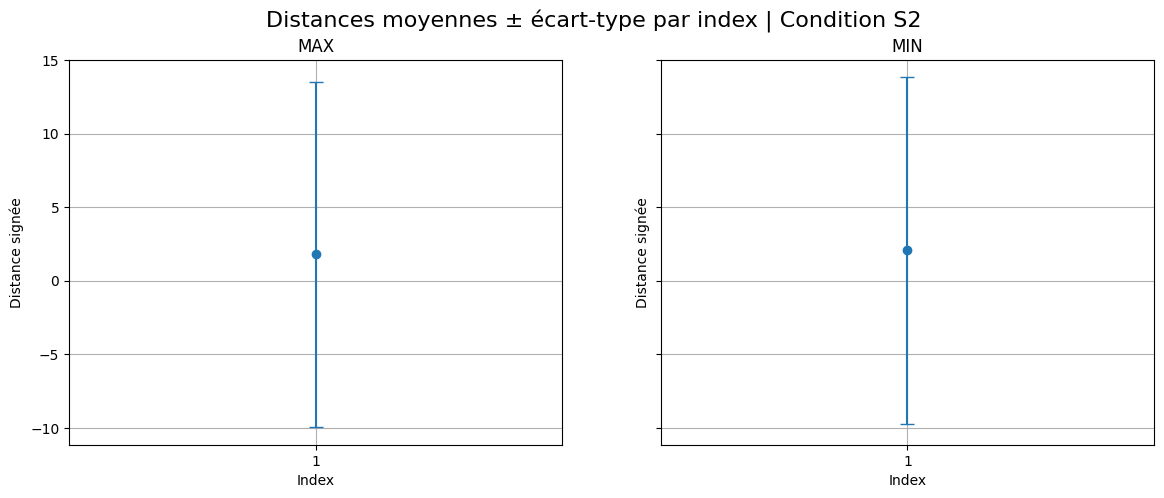

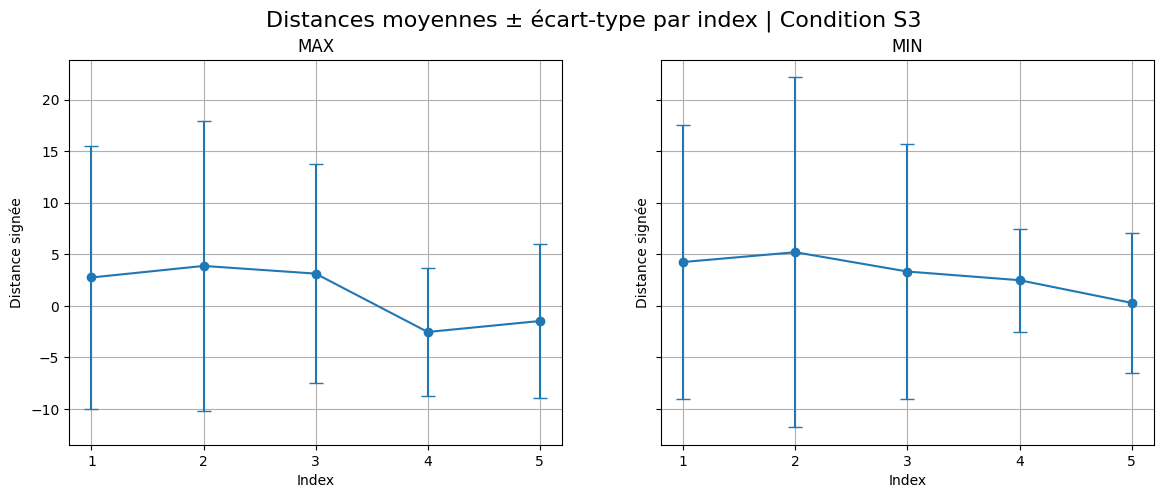

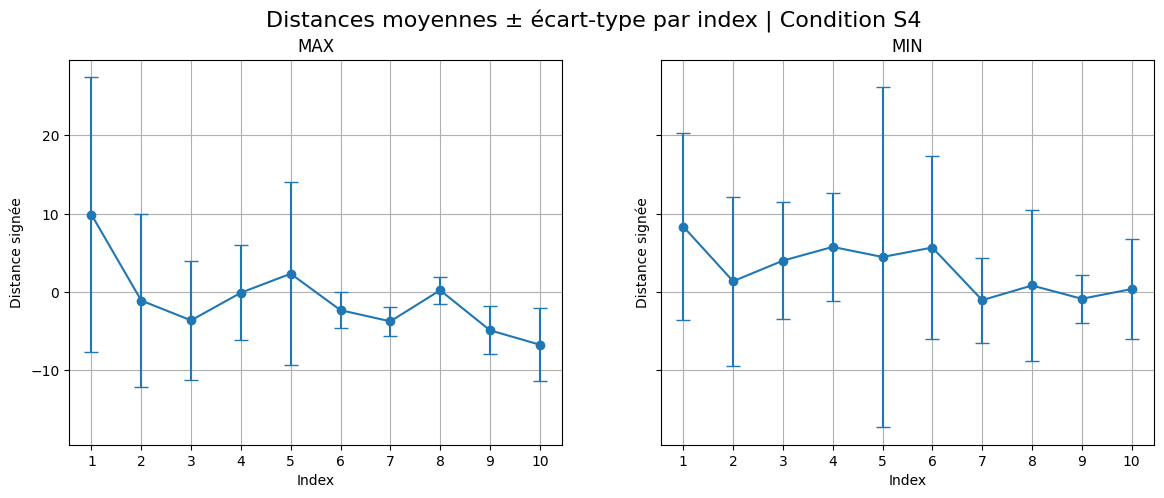

In [5]:
# =========================================================
# 🔷 1) DataFrame distances signées (inchangé)
# =========================================================

from matplotlib import pyplot as plt

# ====== STOCKAGE ======
distances_extrema = []

for _, row in df_extrema.iterrows():
    
    plan = df_plans[
        (df_plans["Sujet"] == row["Sujet"]) & 
        (df_plans["Condition"] == row["Condition"]) & 
        (df_plans["Bloc"] == row["Bloc"])
    ]
    if plan.empty:
        continue
    plan = plan.iloc[0]
    
    n = np.array([plan.Normal_X, plan.Normal_Y, plan.Normal_Z])
    p = np.array([row["X"], row["Y"], row["Z"]])
    
    cols_xyz_block = [
        f"{row['Sujet']}_{row['Condition']}_{row['Bloc']}_X",
        f"{row['Sujet']}_{row['Condition']}_{row['Bloc']}_Y",
        f"{row['Sujet']}_{row['Condition']}_{row['Bloc']}_Z"
    ]

    if not all(c in df_final.columns for c in cols_xyz_block):
        continue

    X_block = df_final[cols_xyz_block].values
    p0 = X_block.mean(axis=0)
    
    vec = p - p0
    dist_signed = np.dot(vec, n)
    
    distances_extrema.append({
        "Sujet": row["Sujet"],
        "Condition": row["Condition"],
        "Bloc": row["Bloc"],
        "Type": row["Type"],
        "Index_extrema": row["Index_extrema"],
        "Distance": dist_signed
    })

df_distances = pd.DataFrame(distances_extrema)
print("✅ DataFrame distances créé :", df_distances.shape)
df_distances.head()

# =========================================================
# 🔷 2) DataFrame modulo variable selon condition
# =========================================================

def get_modulo_index(row):
    if "S1" in row["Condition"] or "S2" in row["Condition"]:
        return 1
    elif "S3" in row["Condition"]:
        return ((row["Index_extrema"] - 1) % 5) + 1
    elif "S4" in row["Condition"]:
        return ((row["Index_extrema"] - 1) % 10) + 1
    else:
        return ((row["Index_extrema"] - 1) % 5) + 1  # fallback

df_distances_mod = df_distances.copy()
df_distances_mod["Index_mod"] = df_distances_mod.apply(get_modulo_index, axis=1)

print("✅ DataFrame distances avec modulo variable créé :", df_distances_mod.shape)
df_distances_mod.head()

# =========================================================
# 🔷 3) PLOTS distance moyenne ± écart type par index variable
# =========================================================

conditions = df_distances_mod["Condition"].unique()
types_ext = ["MAX", "MIN"]

for cond in conditions:

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.suptitle(f"Distances moyennes ± écart-type par index | Condition {cond}", fontsize=16)
    
    # définir nombre d’indices à afficher
    if "S1" in cond or "S2" in cond:
        indices = [1]
    elif "S3" in cond:
        indices = [1,2,3,4,5]
    elif "S4" in cond:
        indices = list(range(1,11))
    else:
        indices = [1,2,3,4,5]

    for i, t in enumerate(types_ext):

        ax = axes[i]
        df_plot = df_distances_mod[
            (df_distances_mod["Condition"] == cond) &
            (df_distances_mod["Type"] == t)
        ]
        
        stats = df_plot.groupby("Index_mod")["Distance"].agg(["mean", "std"]).reindex(indices).reset_index()
        
        ax.errorbar(stats["Index_mod"], stats["mean"], yerr=stats["std"], fmt='o-', capsize=5)
        ax.set_title(f"{t}")
        ax.set_xlabel("Index")
        ax.set_ylabel("Distance signée")
        ax.set_xticks(indices)
        ax.grid(True)
    
    plt.show()

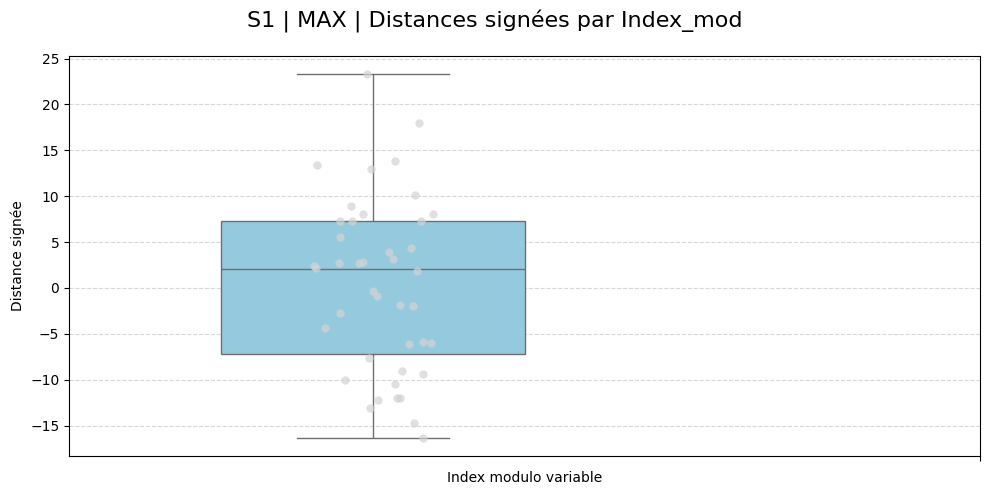

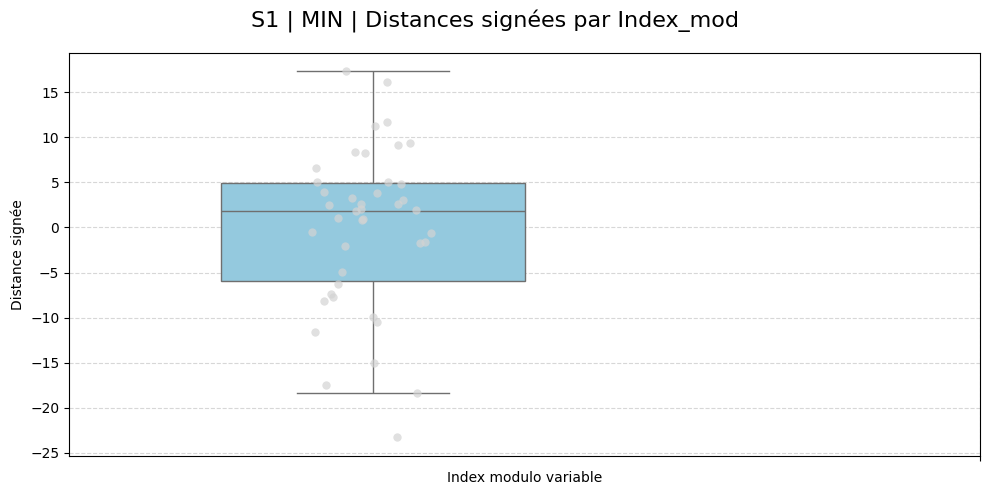

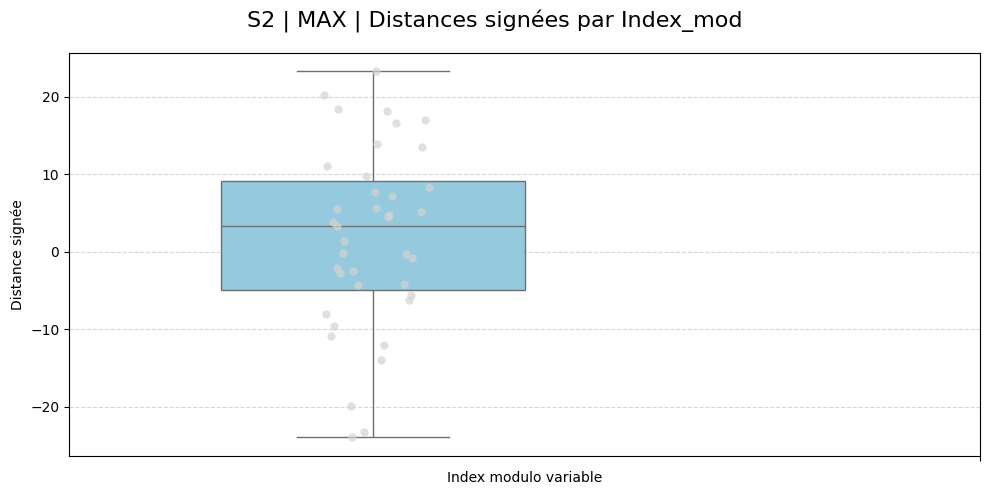

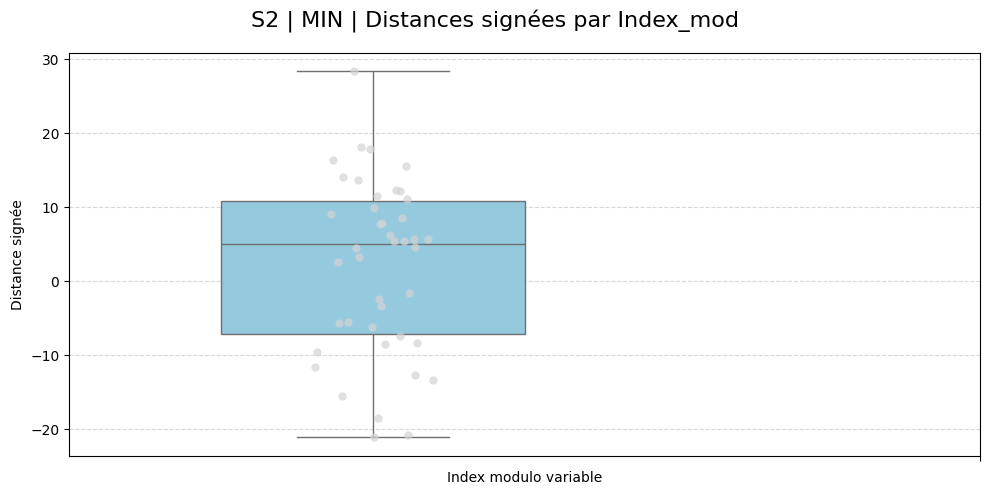

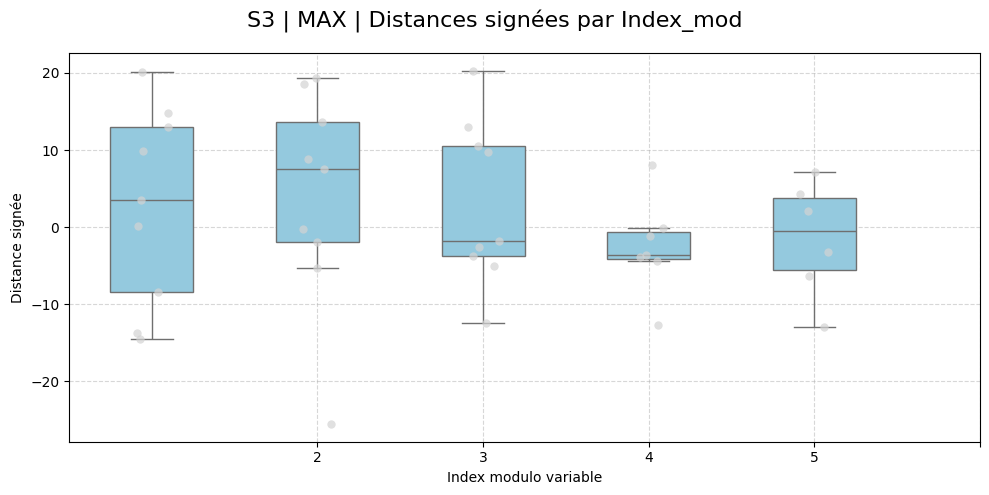

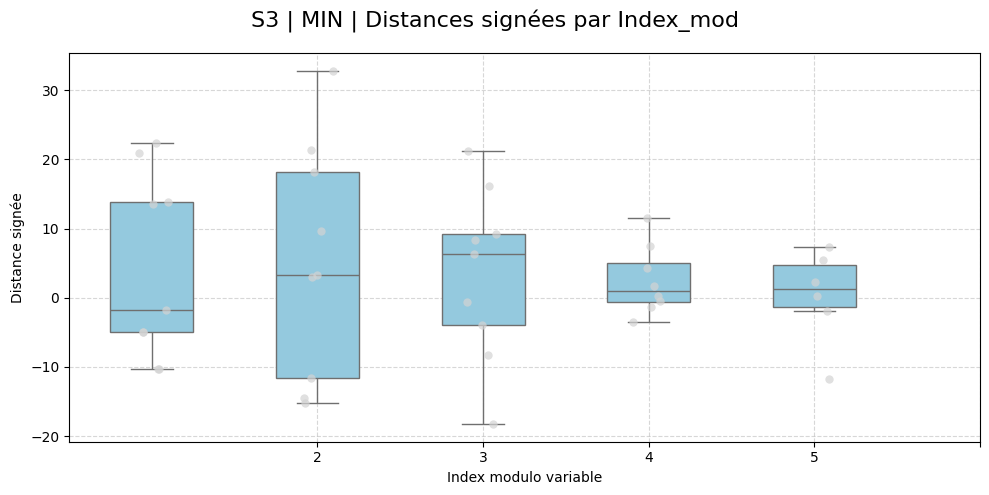

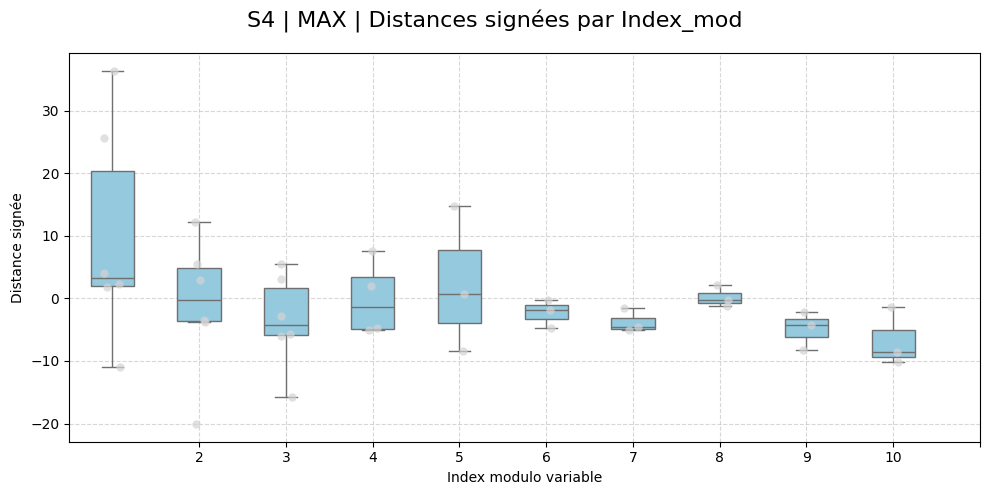

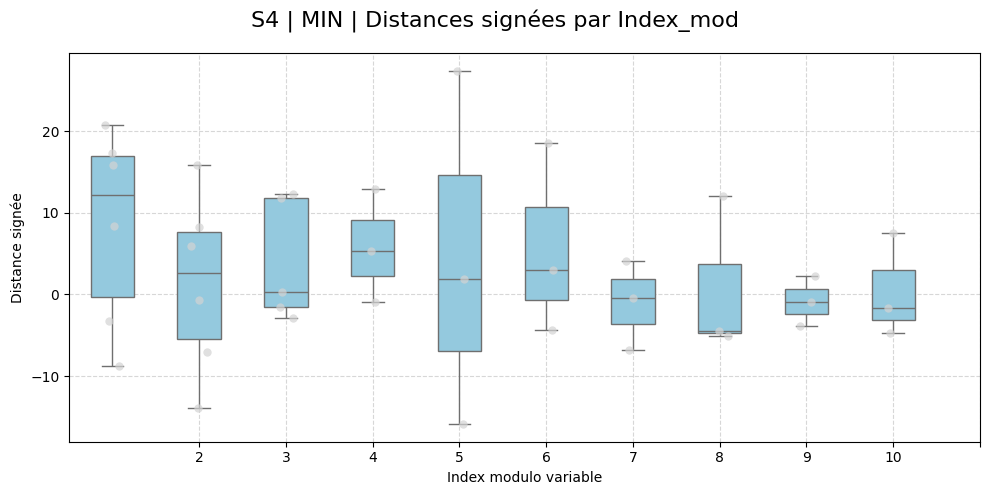

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# ====== CONFIG ======
conditions = df_distances_mod["Condition"].unique()
types_ext = ["MAX", "MIN"]

# Définir condition de référence (sans rotation)
ref_condition = "NoRotation"  # adapter au nom exact
df_ref = df_distances_mod[df_distances_mod["Condition"]==ref_condition]

# ====== Boucle sur conditions ======
for cond in conditions:
    if cond == ref_condition:
        continue  # ne pas comparer la référence avec elle-même
    
    # Déterminer les indices à afficher selon la condition
    if "S1" in cond or "S2" in cond:
        indices = [1]
    elif "S3" in cond:
        indices = [1,2,3,4,5]
    elif "S4" in cond:
        indices = list(range(1,11))
    else:
        indices = sorted(df_distances_mod["Index_mod"].unique())
    
    for typ in types_ext:
        plt.figure(figsize=(10,5))
        plt.suptitle(f"{cond} | {typ} | Distances signées par Index_mod", fontsize=16)
        
        # DataFrame pour la condition testée
        df_plot = df_distances_mod[
            (df_distances_mod["Condition"]==cond) &
            (df_distances_mod["Type"]==typ)
        ]
        
        # ⚡️ Si le DataFrame est vide pour cet index, on ajoute une ligne avec NaN pour forcer l'axe
        for idx in indices:
            if idx not in df_plot["Index_mod"].values:
                df_plot = pd.concat([df_plot, pd.DataFrame({
                    "Sujet": [None],
                    "Condition": [cond],
                    "Bloc": [None],
                    "Type": [typ],
                    "Index_extrema": [None],
                    "Distance": [np.nan],
                    "Index_mod": [idx]
                })], ignore_index=True)
        
        # Boxplot condition testée
        sns.boxplot(
            x="Index_mod",
            y="Distance",
            data=df_plot,
            color="skyblue",
            width=0.5,
            showfliers=False,
            order=indices
        )
        
        # Points individuels en arrière-plan
        sns.stripplot(
            x="Index_mod",
            y="Distance",
            data=df_plot,
            color="lightgray",
            jitter=True,
            size=6,
            alpha=0.7,
            order=indices
        )
        
        # Boxplot condition référence (superposition en rouge)
        df_ref_plot = df_ref[
            (df_ref["Type"]==typ)
        ]
        if not df_ref_plot.empty:
            sns.boxplot(
                x="Index_mod",
                y="Distance",
                data=df_ref_plot,
                color="salmon",
                width=0.3,
                showcaps=True,
                boxprops=dict(alpha=0.5),
                order=indices
            )
        
        plt.xlabel("Index modulo variable")
        plt.ylabel("Distance signée")
        plt.xticks(indices)  # affiche toujours tous les indices
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

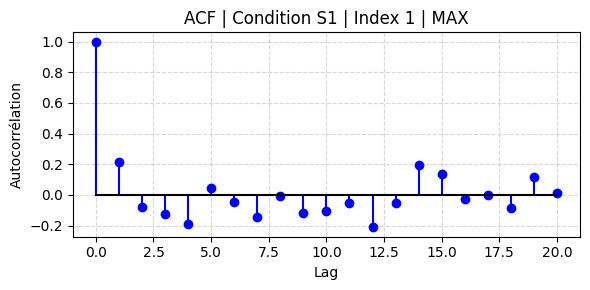

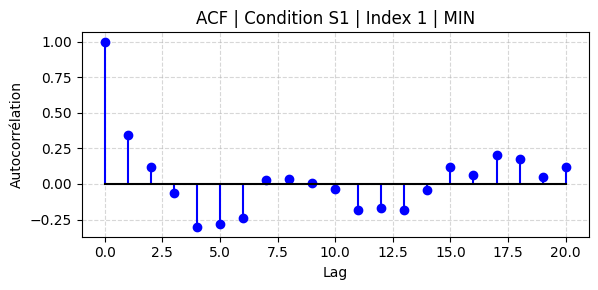

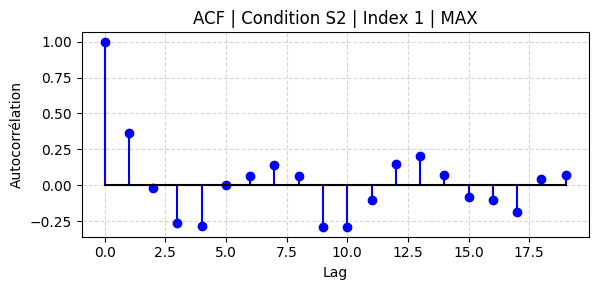

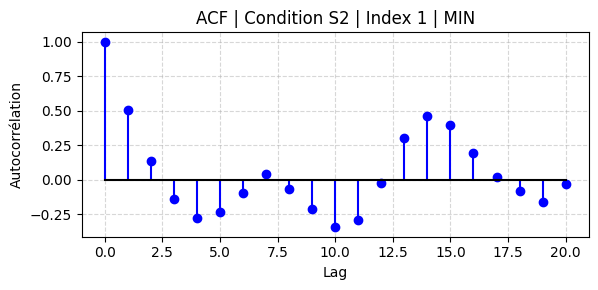

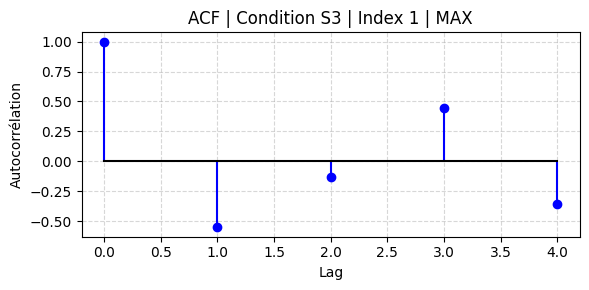

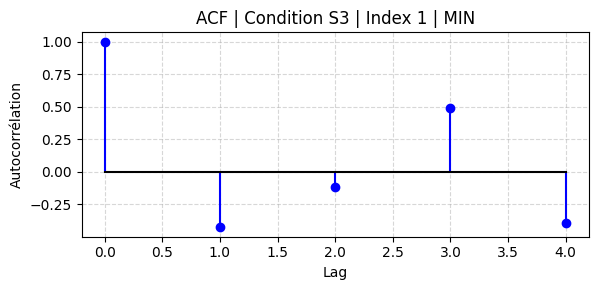

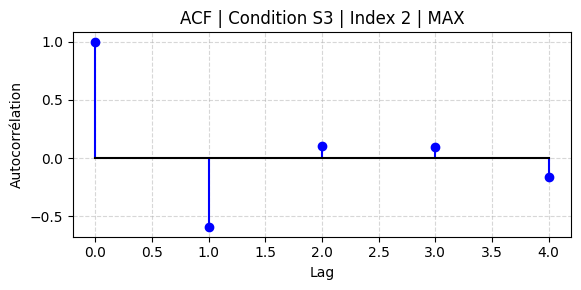

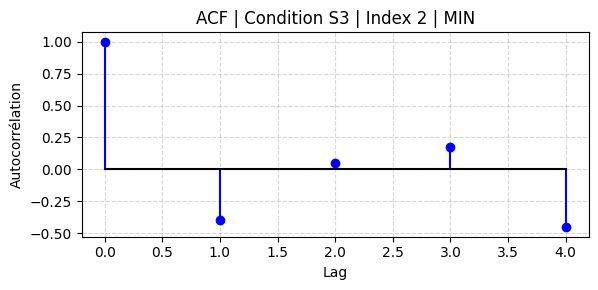

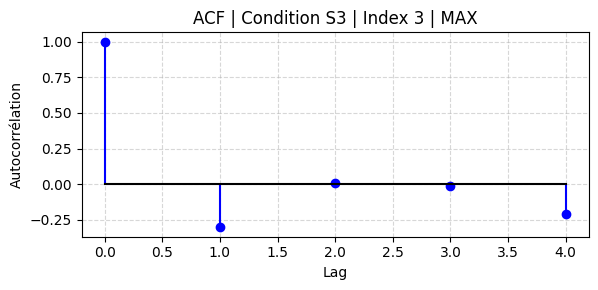

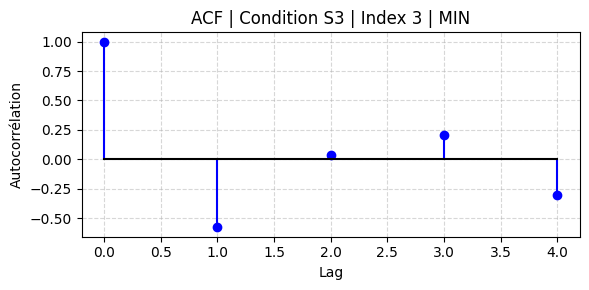

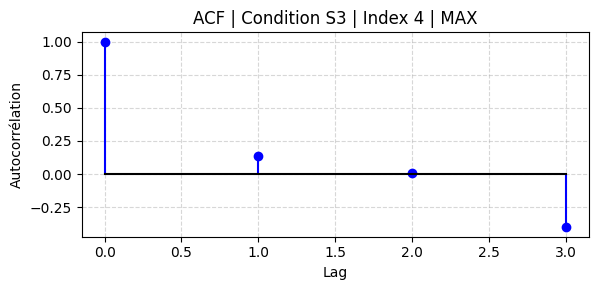

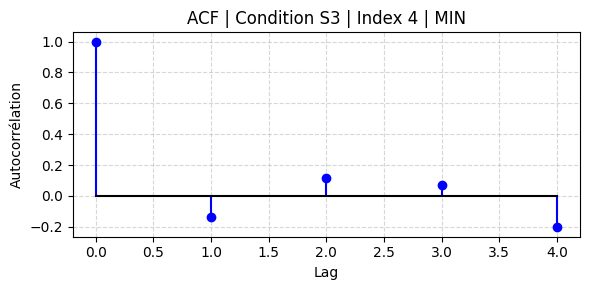

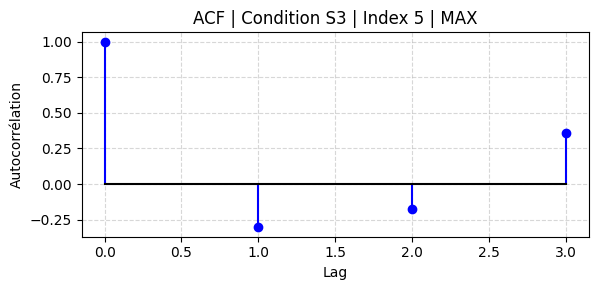

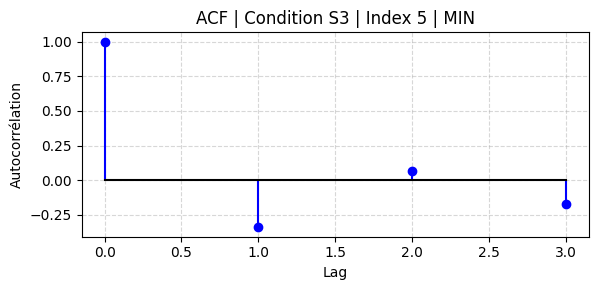

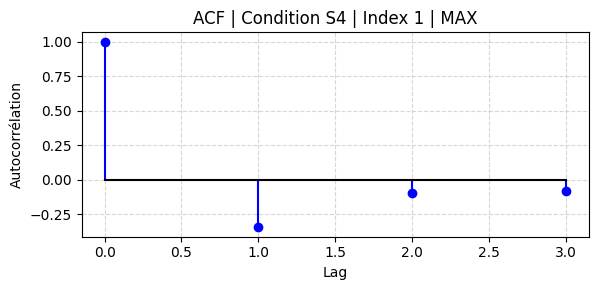

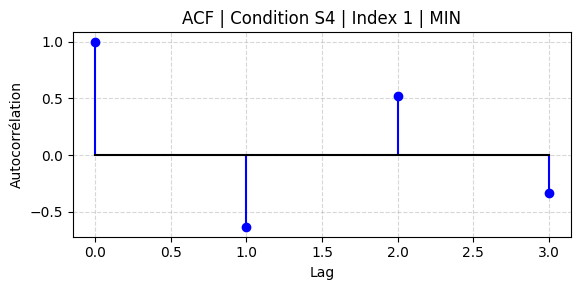

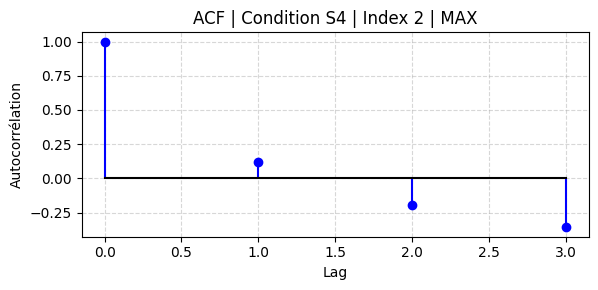

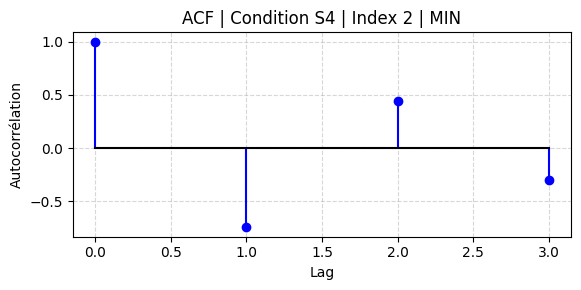

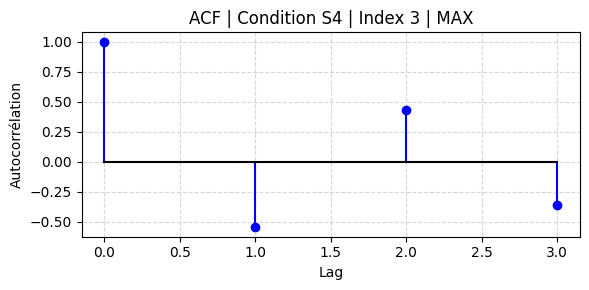

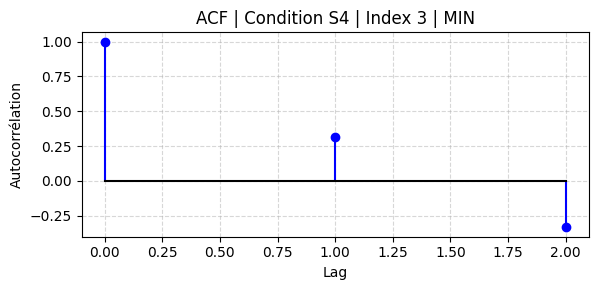

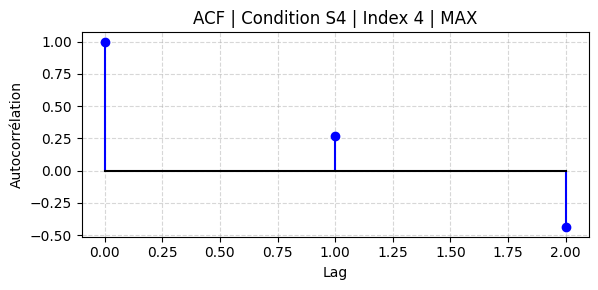

✅ Vérification périodicité terminée : (21, 7)


,Condition,Index_mod,Type,N_points,Q_stat,p_value,periodic
0,S1,1,MAX,42,16.255960,7.006233e-01,False
1,S1,1,MIN,42,31.945707,4.388029e-02,True
2,S2,1,MAX,39,31.913307,3.196437e-02,True
3,S2,1,MIN,42,70.988341,1.255100e-07,True
4,S3,1,MAX,9,9.762230,4.462912e-02,True


In [7]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf
from scipy.stats import chi2
import matplotlib.pyplot as plt

# =========================================================
# 🔷 FONCTION : test statistique périodicité
# =========================================================
def test_periodicity(distances, nlags=None, alpha=0.1):
    """
    distances : array-like des distances signées pour un indice mod
    nlags : nombre de décalages pour autocorrélation
    alpha : seuil significatif
    return : dict { 'acf': acf, 'Q_stat': value, 'p_value': value, 'periodic': bool }
    """
    distances = np.array(distances)
    distances = distances - distances.mean()  # centrer
    
    if len(distances) < 4:
        return {'acf': np.array([]), 'Q_stat': np.nan, 'p_value': np.nan, 'periodic': False}
    
    if nlags is None:
        nlags = min(len(distances)//2, 20)
    
    acf_vals, confint = acf(distances, nlags=nlags, fft=True, alpha=alpha)
    
    # Test de Ljung-Box pour autocorrélation significative
    n = len(distances)
    Q = n*(n+2) * np.sum([acf_vals[k]**2/(n-k) for k in range(1, nlags+1)])
    p_val = 1 - chi2.cdf(Q, df=nlags)
    
    periodic = p_val < alpha
    return {'acf': acf_vals, 'Q_stat': Q, 'p_value': p_val, 'periodic': periodic}


# =========================================================
# 🔷 ANALYSE PAR CONDITION ET INDEX MOD
# =========================================================
results_periodicity = []

conditions = df_distances_mod["Condition"].unique()
types_ext = ["MAX","MIN"]

for cond in conditions:
    # déterminer indices selon condition
    if "S1" in cond or "S2" in cond:
        indices = [1]
    elif "S3" in cond:
        indices = [1,2,3,4,5]
    elif "S4" in cond:
        indices = list(range(1,11))
    else:
        continue
    
    for idx in indices:
        subset_idx = df_distances_mod[
            (df_distances_mod["Condition"]==cond) &
            (df_distances_mod["Index_mod"]==idx)
        ]
        if subset_idx.empty:
            continue
        
        for typ in types_ext:
            dist_typ = subset_idx[subset_idx["Type"]==typ]["Distance"].values
            if len(dist_typ) < 4:  # pas assez de points pour test fiable
                continue
            
            stat = test_periodicity(dist_typ)
            results_periodicity.append({
                "Condition": cond,
                "Index_mod": idx,
                "Type": typ,
                "N_points": len(dist_typ),
                "Q_stat": stat["Q_stat"],
                "p_value": stat["p_value"],
                "periodic": stat["periodic"]
            })
            
            # plot autocorrélation
            plt.figure(figsize=(6,3))
            markerline, stemlines, baseline = plt.stem(stat["acf"], linefmt='b-', markerfmt='bo', basefmt='k-')
            plt.setp(markerline, markersize=6)
            plt.title(f"ACF | Condition {cond} | Index {idx} | {typ}")
            plt.xlabel("Lag")
            plt.ylabel("Autocorrélation")
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.tight_layout()
            plt.show()

# DataFrame récapitulatif
df_periodicity = pd.DataFrame(results_periodicity)
print("✅ Vérification périodicité terminée :", df_periodicity.shape)
df_periodicity.head()

In [8]:
# Trier df_periodicity selon l'ordre des conditions L1, S2, S3, S4
order_conditions = ["S1", "S2", "S3", "S4"]

# Ajouter une colonne temporaire pour trier selon l'ordre
df_periodicity["S_order"] = df_periodicity["Condition"].apply(lambda x: next((i for i, l in enumerate(order_conditions) if l in x), 99))

# Tri final
df_periodicity_sorted = df_periodicity.sort_values(
    by=["S_order", "Condition", "Index_mod", "Type"]
).reset_index(drop=True)

# Supprimer colonne temporaire
df_periodicity_sorted = df_periodicity_sorted.drop(columns=["S_order"])

# Affichage
print(df_periodicity_sorted)

   Condition  Index_mod Type  N_points     Q_stat       p_value  periodic
0         S1          1  MAX        42  16.255960  7.006233e-01     False
1         S1          1  MIN        42  31.945707  4.388029e-02      True
2         S2          1  MAX        39  31.913307  3.196437e-02      True
3         S2          1  MIN        42  70.988341  1.255100e-07      True
4         S3          1  MAX         9   9.762230  4.462912e-02      True
5         S3          1  MIN         9   9.451955  5.074387e-02      True
6         S3          2  MAX         9   5.236550  2.638756e-01     False
7         S3          2  MIN         9   6.625703  1.570404e-01     False
8         S3          3  MAX         9   1.983282  7.388340e-01     False
9         S3          3  MIN         9   6.659203  1.550317e-01     False
10        S3          4  MAX         7   2.767342  4.289043e-01     False
11        S3          4  MIN         8   1.316310  8.586023e-01     False
12        S3          5  MAX         6

In [9]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# =========================================================
# 🔷 ANALYSE HARMONIQUE DES DISTANCES
# =========================================================

results_harmonic = []

conditions = df_distances_mod["Condition"].unique()
types_ext = ["MAX", "MIN"]

for cond in conditions:
    
    # Déterminer le nombre d’indices selon la condition
    if "S1" in cond or "S2" in cond:
        N = 1  # pas de périodicité possible
    elif "S3" in cond:
        N = 5
    elif "S4" in cond:
        N = 10
    else:
        continue
    
    # On ignore S1 et S2 pour l'analyse périodique
    if N == 1:
        continue
    
    for typ in types_ext:
        df_sub = df_distances_mod[
            (df_distances_mod["Condition"] == cond) &
            (df_distances_mod["Type"] == typ)
        ].copy()
        
        if len(df_sub) < 10:
            print(f"⚠️ Pas assez de points pour {cond} - {typ}")
            continue
        
        # Calcul de la phase angulaire
        df_sub["theta"] = 2 * np.pi * (df_sub["Index_mod"] - 1) / N
        df_sub["sin_theta"] = np.sin(df_sub["theta"])
        df_sub["cos_theta"] = np.cos(df_sub["theta"])
        
        # Modèle harmonique avec API formula
        model = smf.ols(
            formula="Distance ~ sin_theta + cos_theta",
            data=df_sub
        ).fit()
        
        # Test global de la composante sinusoïdale
        anova_res = anova_lm(model, typ=2)
        p_value_global = anova_res.loc["sin_theta", "PR(>F)"]
        
        # Amplitude et phase
        beta1 = model.params["sin_theta"]
        beta2 = model.params["cos_theta"]
        amplitude = np.sqrt(beta1**2 + beta2**2)
        phase = np.arctan2(beta2, beta1)
        
        results_harmonic.append({
            "Condition": cond,
            "Type": typ,
            "N_points": len(df_sub),
            "Amplitude": amplitude,
            "Phase_rad": phase,
            "R_squared": model.rsquared,
            "p_value_sin": model.pvalues["sin_theta"],
            "p_value_cos": model.pvalues["cos_theta"],
            "p_value_global": model.f_pvalue  # Test global du modèle
        })
        
        print(f"\n📊 Condition {cond} | {typ}")
        print(model.summary())

# DataFrame récapitulatif
df_harmonic = pd.DataFrame(results_harmonic)
print("\n✅ Résumé des modèles harmoniques :")
print(df_harmonic)


📊 Condition S3 | MAX
                            OLS Regression Results                            
Dep. Variable:               Distance   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.004
Date:                Thu, 16 Apr 2026   Prob (F-statistic):              0.376
Time:                        10:38:27   Log-Likelihood:                -150.42
No. Observations:                  40   AIC:                             306.8
Df Residuals:                      37   BIC:                             311.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1732      1.7

Conditions analysées : ['S3' 'S4']

✅ Exemple du DataFrame combiné :
  Sujet Condition Bloc Type  Index_extrema   Distance  Index_mod  Index_seq  \
0   S04        S3   19  MAX              1  13.001990          1          1   
1   S04        S3   19  MIN              1  13.811103          1          2   
2   S04        S3   19  MAX              2   7.583250          2          3   
3   S04        S3   19  MIN              2  21.292525          2          4   
4   S04        S3   19  MAX              3   9.756191          3          5   

   N_period  Index_mod_combined  
0        10                   1  
1        10                   2  
2        10                   3  
3        10                   4  
4        10                   5  

📊 Condition S3 (MAX + MIN combinés)
                            OLS Regression Results                            
Dep. Variable:               Distance   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:  

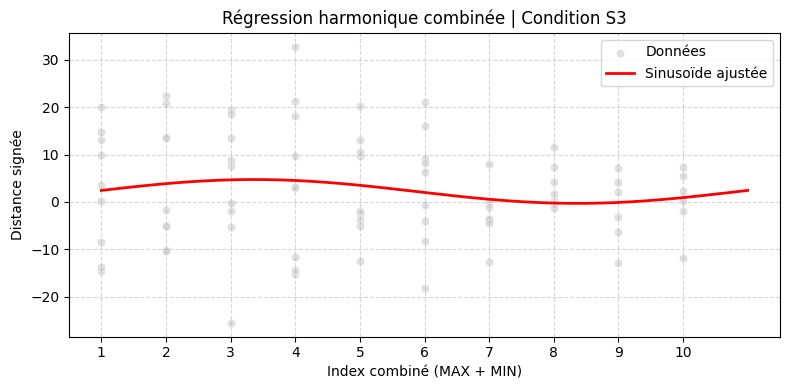


📊 Condition S4 (MAX + MIN combinés)
                            OLS Regression Results                            
Dep. Variable:               Distance   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                 -0.013
Method:                 Least Squares   F-statistic:                    0.5077
Date:                Thu, 16 Apr 2026   Prob (F-statistic):              0.604
Time:                        10:38:28   Log-Likelihood:                -289.08
No. Observations:                  78   AIC:                             584.2
Df Residuals:                      75   BIC:                             591.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      

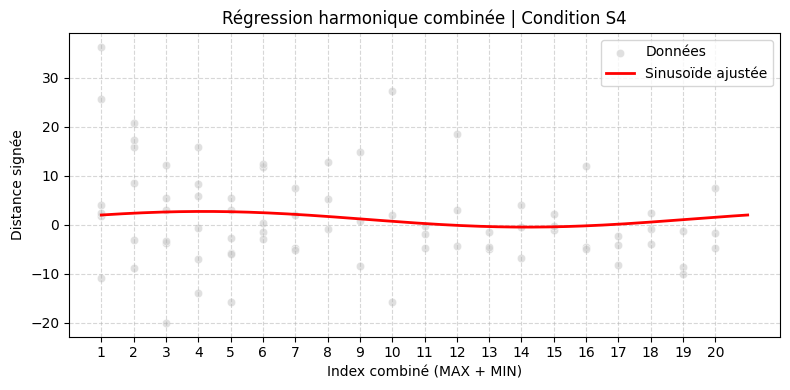


✅ Résumé des modèles harmoniques combinés :
  Condition  N_points  Amplitude  Phase_rad  R_squared  p_value_global
0        S3        81   2.519021   0.086309   0.024427        0.381178
1        S4        78   1.599287   0.576656   0.013359        0.603907


In [10]:
# =========================================================
# 🔷 ANALYSE HARMONIQUE COMBINANT MAX ET MIN (S3 & S4)
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# =========================================================
# 🔷 1. SELECTION DES CONDITIONS S3 ET S4
# =========================================================
df_combined = df_distances_mod.copy()
df_combined = df_combined[df_combined["Condition"].isin(["S3", "S4"])]

# Vérification
print("Conditions analysées :", df_combined["Condition"].unique())

# =========================================================
# 🔷 2. CREATION D'UN INDICE SEQUENTIEL PAR BLOC
# =========================================================
# Trier selon l'ordre temporel des extrema
df_combined = df_combined.sort_values(
    by=["Sujet", "Condition", "Bloc", "Index_extrema"]
).reset_index(drop=True)

# Indice séquentiel (MAX et MIN combinés)
df_combined["Index_seq"] = (
    df_combined
    .groupby(["Sujet", "Condition", "Bloc"])
    .cumcount() + 1
)

# =========================================================
# 🔷 3. CREATION DE L'INDICE MODULO ADAPTE A LA PERIODE
# =========================================================
def get_period(cond):
    """Retourne le nombre d'indices combinés pour chaque condition."""
    if cond == "S3":
        return 10   # 5 positions sonores * (MAX + MIN)
    elif cond == "S4":
        return 20   # 10 positions sonores * (MAX + MIN)
    else:
        return np.nan

df_combined["N_period"] = df_combined["Condition"].apply(get_period)

# Calcul de l'indice modulo
df_combined["Index_mod_combined"] = (
    (df_combined["Index_seq"] - 1) % df_combined["N_period"]
) + 1

print("\n✅ Exemple du DataFrame combiné :")
print(df_combined.head())

# =========================================================
# 🔷 4. REGRESSION HARMONIQUE
# =========================================================
results_harmonic = []

for cond in ["S3", "S4"]:
    
    df_cond = df_combined[df_combined["Condition"] == cond].copy()
    N = int(df_cond["N_period"].iloc[0])
    
    # Calcul de la phase angulaire
    df_cond["theta"] = 2 * np.pi * (df_cond["Index_mod_combined"] - 1) / N
    df_cond["sin_theta"] = np.sin(df_cond["theta"])
    df_cond["cos_theta"] = np.cos(df_cond["theta"])
    
    # Régression harmonique
    model = smf.ols(
        formula="Distance ~ sin_theta + cos_theta",
        data=df_cond
    ).fit()
    
    # Calcul amplitude et phase
    beta1 = model.params["sin_theta"]
    beta2 = model.params["cos_theta"]
    amplitude = np.sqrt(beta1**2 + beta2**2)
    phase = np.arctan2(beta2, beta1)
    
    results_harmonic.append({
        "Condition": cond,
        "N_points": len(df_cond),
        "Amplitude": amplitude,
        "Phase_rad": phase,
        "R_squared": model.rsquared,
        "p_value_global": model.f_pvalue
    })
    
    # Affichage du résumé statistique
    print(f"\n📊 Condition {cond} (MAX + MIN combinés)")
    print(model.summary())
    
    # =====================================================
    # 🔷 5. VISUALISATION DE LA SINUSOIDE AJUSTEE
    # =====================================================
    theta_vals = np.linspace(0, 2 * np.pi, 300)
    pred = (
        model.params["Intercept"]
        + beta1 * np.sin(theta_vals)
        + beta2 * np.cos(theta_vals)
    )
    
    index_vals = (theta_vals / (2 * np.pi)) * N + 1
    
    plt.figure(figsize=(8, 4))
    sns.scatterplot(
        x="Index_mod_combined",
        y="Distance",
        data=df_cond,
        color="lightgray",
        alpha=0.7,
        label="Données"
    )
    
    plt.plot(index_vals, pred, color="red", linewidth=2,
             label="Sinusoïde ajustée")
    
    plt.title(f"Régression harmonique combinée | Condition {cond}")
    plt.xlabel("Index combiné (MAX + MIN)")
    plt.ylabel("Distance signée")
    plt.xticks(range(1, N + 1))
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

# =========================================================
# 🔷 6. DATAFRAME RECAPITULATIF
# =========================================================
df_harmonic_combined = pd.DataFrame(results_harmonic)

print("\n✅ Résumé des modèles harmoniques combinés :")
print(df_harmonic_combined)

S2 MAX: 1.7830769593123477
S2 MIN: 2.0599148924651964

📊 S3 | MAX
                            OLS Regression Results                            
Dep. Variable:          Distance_corr   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.004
Date:                Thu, 16 Apr 2026   Prob (F-statistic):              0.376
Time:                        10:38:28   Log-Likelihood:                -150.42
No. Observations:                  40   AIC:                             306.8
Df Residuals:                      37   BIC:                             311.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

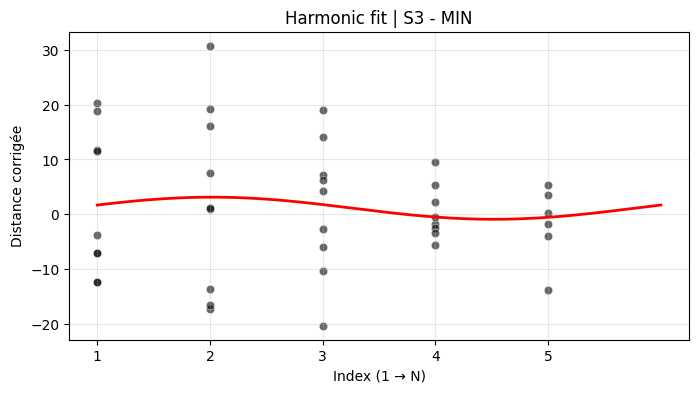


📊 S4 | MAX
                            OLS Regression Results                            
Dep. Variable:          Distance_corr   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                 -0.031
Method:                 Least Squares   F-statistic:                    0.4139
Date:                Thu, 16 Apr 2026   Prob (F-statistic):              0.664
Time:                        10:38:29   Log-Likelihood:                -147.67
No. Observations:                  40   AIC:                             301.3
Df Residuals:                      37   BIC:                             306.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.5228      1.661     -1.

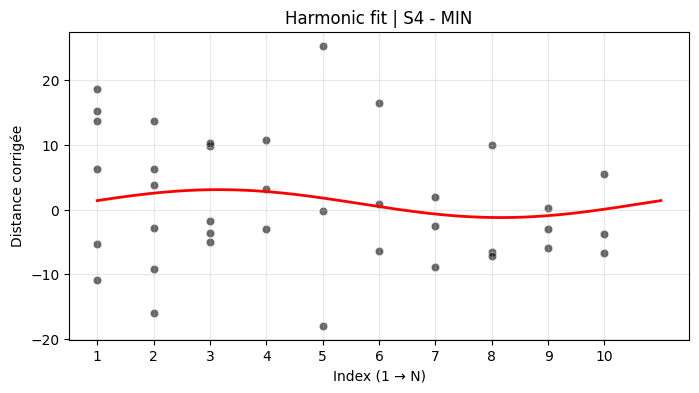

  Condition Type  Amplitude        R2         p
0        S3  MAX   3.530196  0.051482  0.376134
1        S3  MIN   2.018552  0.014670  0.755191
2        S4  MAX   2.052495  0.021881  0.664114
3        S4  MIN   2.157406  0.023787  0.656186


In [11]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1) BASELINE S2
# =========================================================

df_S2 = df_distances_mod[df_distances_mod["Condition"] == "S2"]

S2_mean_max = df_S2[df_S2["Type"] == "MAX"]["Distance"].mean()
S2_mean_min = df_S2[df_S2["Type"] == "MIN"]["Distance"].mean()

print("S2 MAX:", S2_mean_max)
print("S2 MIN:", S2_mean_min)

# =========================================================
# 2) S3 + S4 + CORRECTION
# =========================================================

df = df_distances_mod[df_distances_mod["Condition"].isin(["S3", "S4"])].copy()

df["Distance_corr"] = np.where(
    df["Type"] == "MAX",
    df["Distance"] - S2_mean_max,
    df["Distance"] - S2_mean_min
)

# =========================================================
# 3) 🔥 RECONSTRUCTION PROPRE DES INDICES (MODULO)
# =========================================================

# ordre stable dans chaque condition
df = df.sort_values(["Condition", "Bloc"]).copy()

# compteur global dans chaque condition + type (IMPORTANT)
df["Index_clean"] = df.groupby(["Condition", "Type", "Bloc"]).cumcount()

# N dépend de la condition
df["N"] = df["Condition"].map({"S3": 5, "S4": 10})

# MODULO PROPRE → 1..N
df["Index_phase"] = (df["Index_clean"] % df["N"]) + 1

# =========================================================
# 4) HARMONIQUE
# =========================================================

results = []

for cond in ["S3", "S4"]:
    N = 5 if cond == "S3" else 10

    for typ in ["MAX", "MIN"]:

        df_sub = df[(df["Condition"] == cond) & (df["Type"] == typ)].copy()

        if len(df_sub) < 10:
            print(f"⚠️ Pas assez de points {cond}-{typ}")
            continue

        # harmonique sur INDEX PROPRE
        df_sub["theta"] = 2 * np.pi * (df_sub["Index_phase"] - 1) / N
        df_sub["sin_theta"] = np.sin(df_sub["theta"])
        df_sub["cos_theta"] = np.cos(df_sub["theta"])

        model = smf.ols(
            "Distance_corr ~ sin_theta + cos_theta",
            data=df_sub
        ).fit()

        beta1 = model.params["sin_theta"]
        beta2 = model.params["cos_theta"]

        results.append({
            "Condition": cond,
            "Type": typ,
            "Amplitude": np.sqrt(beta1**2 + beta2**2),
            "R2": model.rsquared,
            "p": model.f_pvalue
        })

        print(f"\n📊 {cond} | {typ}")
        print(model.summary())

        # =====================================================
    # 5) PLOT PROPRE (sans distinction des blocs)
    # =====================================================
    
    plt.figure(figsize=(8, 4))
    
    sns.scatterplot(
        data=df_sub,
        x="Index_phase",
        y="Distance_corr",
        color="black",   # 🔥 plus de séparation par bloc
        alpha=0.6
    )
    
    theta_grid = np.linspace(0, 2*np.pi, 300)
    
    pred = (
        model.params["Intercept"]
        + beta1 * np.sin(theta_grid)
        + beta2 * np.cos(theta_grid)
    )
    
    x_grid = (theta_grid / (2*np.pi)) * N + 1
    
    plt.plot(x_grid, pred, color="red", linewidth=2)
    
    plt.xticks(range(1, N + 1))
    plt.title(f"Harmonic fit | {cond} - {typ}")
    plt.xlabel("Index (1 → N)")
    plt.ylabel("Distance corrigée")
    plt.grid(alpha=0.3)
    
    plt.show()

# =========================================================
# 6) RESULTATS
# =========================================================

df_results = pd.DataFrame(results)
print(df_results)

✅ S2 MAX mean: 1.7830769593123477
✅ S2 MIN mean: 2.0599148924651964


C:\Users\nicom\AppData\Local\Temp\ipykernel_5752\189410682.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(create_periodic_index)



✅ Aperçu des indices périodiques :
   Sujet Condition Bloc Type  Index_extrema  Index_phase
0    S04        S3   19  MAX              1            1
1    S04        S3   19  MIN              1            2
2    S04        S3   19  MAX              2            3
3    S04        S3   19  MIN              2            4
4    S04        S3   19  MAX              3            5
5    S04        S3   19  MIN              3            6
6    S04        S3   19  MAX              4            7
7    S04        S3   19  MIN              4            8
8    S04        S3   19  MAX              5            9
9    S04        S3   19  MIN              5           10
10   S04        S3   19  MAX              6            1
11   S04        S3   19  MIN              6            2
12   S04        S3   19  MAX              7            3
13   S04        S3   19  MIN              7            4
14   S04        S3   19  MAX              8            5
15   S04        S3   19  MIN              8         

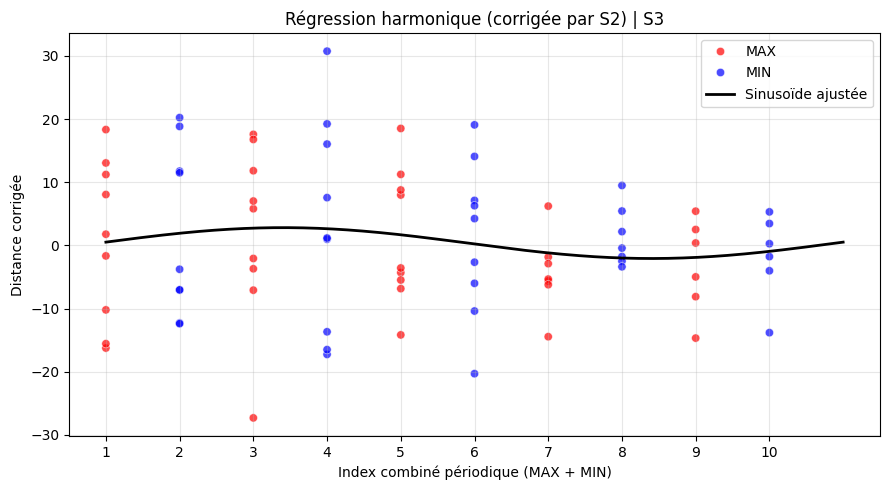


📊 Condition S4 (MAX + MIN combinés)
                            OLS Regression Results                            
Dep. Variable:          Distance_corr   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.8694
Date:                Thu, 16 Apr 2026   Prob (F-statistic):              0.424
Time:                        10:38:31   Log-Likelihood:                -280.35
No. Observations:                  76   AIC:                             566.7
Df Residuals:                      73   BIC:                             573.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -

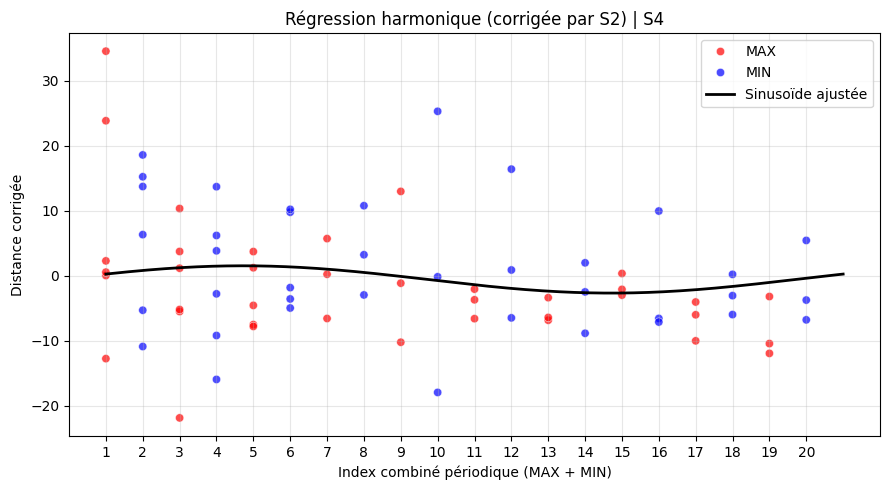


✅ Résumé des modèles harmoniques combinés :
  Condition  N_points  Amplitude  Phase_rad  R_squared  p_value_global
0        S3        80   2.443665   0.060761   0.022751        0.412283
1        S4        76   2.100126   0.403899   0.023265        0.423503


In [13]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1) BASELINE S2
# =========================================================
df_S2 = df_distances_mod[df_distances_mod["Condition"] == "S2"]

S2_mean_max = df_S2[df_S2["Type"] == "MAX"]["Distance"].mean()
S2_mean_min = df_S2[df_S2["Type"] == "MIN"]["Distance"].mean()

print("✅ S2 MAX mean:", S2_mean_max)
print("✅ S2 MIN mean:", S2_mean_min)

# =========================================================
# 2) SELECTION S3 ET S4 + CORRECTION PAR S2
# =========================================================
df = df_distances_mod[
    df_distances_mod["Condition"].isin(["S3", "S4"])
].copy()

df["Distance_corr"] = np.where(
    df["Type"] == "MAX",
    df["Distance"] - S2_mean_max,
    df["Distance"] - S2_mean_min
)

# =========================================================
# 3) CREATION DE L'INDEX COMBINE AVEC PERIODICITE
# =========================================================
# Tri des données
df = df.sort_values(
    by=["Sujet", "Condition", "Bloc", "Index_extrema"]
).reset_index(drop=True)

def create_periodic_index(group):
    """
    Crée un index alterné MAX/MIN avec répétition périodique :
    S3 : période de 10
    S4 : période de 20
    """
    cond = group["Condition"].iloc[0]
    N = 10 if cond == "S3" else 20

    max_df = group[group["Type"] == "MAX"].sort_values("Index_extrema").reset_index(drop=True)
    min_df = group[group["Type"] == "MIN"].sort_values("Index_extrema").reset_index(drop=True)

    n_pairs = min(len(max_df), len(min_df))
    rows = []

    for i in range(n_pairs):
        # Index séquentiel
        seq_max = 2 * i + 1
        seq_min = 2 * i + 2

        # Application du modulo périodique
        phase_max = ((seq_max - 1) % N) + 1
        phase_min = ((seq_min - 1) % N) + 1

        # MAX
        r_max = max_df.iloc[i].copy()
        r_max["Index_phase"] = phase_max
        r_max["N"] = N
        rows.append(r_max)

        # MIN
        r_min = min_df.iloc[i].copy()
        r_min["Index_phase"] = phase_min
        r_min["N"] = N
        rows.append(r_min)

    return pd.DataFrame(rows)

# Application par Sujet / Condition / Bloc
df_combined = (
    df.groupby(["Sujet", "Condition", "Bloc"], group_keys=False)
    .apply(create_periodic_index)
    .reset_index(drop=True)
)

# Vérification
print("\n✅ Aperçu des indices périodiques :")
print(df_combined[["Sujet", "Condition", "Bloc", "Type", "Index_extrema", "Index_phase"]].head(20))

# =========================================================
# 4) REGRESSION HARMONIQUE
# =========================================================
results = []

for cond in ["S3", "S4"]:
    
    df_sub = df_combined[df_combined["Condition"] == cond].copy()
    N = 10 if cond == "S3" else 20

    if df_sub.empty:
        print(f"⚠️ Pas de données pour {cond}")
        continue

    # Calcul de la phase angulaire
    df_sub["theta"] = 2 * np.pi * (df_sub["Index_phase"] - 1) / N
    df_sub["sin_theta"] = np.sin(df_sub["theta"])
    df_sub["cos_theta"] = np.cos(df_sub["theta"])

    # Modèle harmonique
    model = smf.ols(
        "Distance_corr ~ sin_theta + cos_theta",
        data=df_sub
    ).fit()

    beta1 = model.params["sin_theta"]
    beta2 = model.params["cos_theta"]

    amplitude = np.sqrt(beta1**2 + beta2**2)
    phase = np.arctan2(beta2, beta1)

    results.append({
        "Condition": cond,
        "N_points": len(df_sub),
        "Amplitude": amplitude,
        "Phase_rad": phase,
        "R_squared": model.rsquared,
        "p_value_global": model.f_pvalue
    })

    print(f"\n📊 Condition {cond} (MAX + MIN combinés)")
    print(model.summary())

    # =====================================================
    # 5) VISUALISATION
    # =====================================================
    plt.figure(figsize=(9, 5))

    sns.scatterplot(
        data=df_sub,
        x="Index_phase",
        y="Distance_corr",
        hue="Type",
        palette={"MAX": "red", "MIN": "blue"},
        alpha=0.7
    )

    # Sinusoïde ajustée
    theta_grid = np.linspace(0, 2 * np.pi, 300)
    pred = (
        model.params["Intercept"]
        + beta1 * np.sin(theta_grid)
        + beta2 * np.cos(theta_grid)
    )
    x_grid = (theta_grid / (2 * np.pi)) * N + 1

    plt.plot(x_grid, pred, color="black", linewidth=2,
             label="Sinusoïde ajustée")

    plt.xticks(range(1, N + 1))
    plt.title(f"Régression harmonique (corrigée par S2) | {cond}")
    plt.xlabel("Index combiné périodique (MAX + MIN)")
    plt.ylabel("Distance corrigée")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# =========================================================
# 6) DATAFRAME RECAPITULATIF
# =========================================================
df_results = pd.DataFrame(results)

print("\n✅ Résumé des modèles harmoniques combinés :")
print(df_results)